# 02 · Data Augmentation

Genera variantes artificiales de los landmarks extraídos para aumentar el dataset.
Opera sobre archivos `.npy`, no sobre los videos originales.

**Transformaciones aplicadas:**
- Volteo horizontal — simula zurdo/diestro
- Ruido gaussiano — simula variaciones entre personas
- Escala aleatoria — simula distancia a la cámara
- Recorte temporal — simula diferentes velocidades de ejecución
- Rotación en plano XY — simula ligeros cambios de ángulo

**Input:** `data/landmarks/{CLASE}/*.npy` — shape `(n_frames, 2, 21, 3)`  
**Output:** `data/landmarks_aug/{CLASE}/*.npy` — misma estructura, más ejemplos

## Setup

In [8]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import shutil

LANDMARKS_DIR = Path('./data/landmarks')
AUG_DIR       = Path('./data/landmarks_aug')
AUG_DIR.mkdir(parents=True, exist_ok=True)

# Clases detectadas automáticamente
CLASES = [c.name for c in sorted(LANDMARKS_DIR.iterdir()) if c.is_dir()]

# Cuántas variantes generar por clip original
N_AUG = 5

print(f'Clases encontradas: {CLASES}')
print(f'Variantes por clip: {N_AUG}')
print(f'Landmarks originales en: {LANDMARKS_DIR.resolve()}')
print(f'Augmentados en:          {AUG_DIR.resolve()}')

Clases encontradas: ['DONDE', 'NADA', 'POR_QUE', 'QUE1', 'QUIEN1']
Variantes por clip: 5
Landmarks originales en: /home/pierov/piero/projects/whqlsp-detector/notebooks/data/landmarks
Augmentados en:          /home/pierov/piero/projects/whqlsp-detector/notebooks/data/landmarks_aug


In [9]:
CLASES

['DONDE', 'NADA', 'POR_QUE', 'QUE1', 'QUIEN1']

## Sección 1 — Funciones de augmentation

Cada función recibe un array de shape `(n_frames, 2, 21, 3)` y devuelve uno del mismo shape con la transformación aplicada.

In [16]:
def voltear_horizontal(landmarks: np.ndarray) -> np.ndarray:
    """
    Invierte el eje X de todos los landmarks.
    Simula una persona zurda si el original es diestro, y viceversa.
    Los landmarks de MediaPipe están normalizados en [0, 1],
    así que voltear X es simplemente 1 - x.
    """
    aug = landmarks.copy()
    aug[:, :, :, 0] = 1.0 - landmarks[:, :, :, 0]  # invertir eje X
    # Intercambiar mano derecha (idx 0) e izquierda (idx 1)
    aug[:, 0], aug[:, 1] = aug[:, 1].copy(), aug[:, 0].copy()
    return aug


def agregar_ruido(landmarks: np.ndarray, intensidad: float = 0.01) -> np.ndarray:
    """
    Agrega ruido gaussiano a todos los landmarks.
    Simula pequeñas variaciones de posición entre personas.
    Solo se aplica a frames donde hay detección (no ceros).
    intensidad: desviación estándar del ruido (0.01 = 1% del espacio normalizado)
    """
    aug = landmarks.copy()
    ruido = np.random.normal(0, intensidad, landmarks.shape).astype(np.float32)
    # Máscara: solo donde hay landmarks reales (no frames vacíos)
    mascara = (landmarks != 0).any(axis=(2, 3), keepdims=True)
    mascara = np.broadcast_to(mascara, landmarks.shape)
    aug[mascara] = (landmarks + ruido)[mascara]
    # Clip para mantener coordenadas en rango razonable
    aug = np.clip(aug, -0.5, 1.5)
    return aug


def escalar(landmarks: np.ndarray, factor_min: float = 0.85,
            factor_max: float = 1.15) -> np.ndarray:
    """
    Escala los landmarks alrededor del centro de la imagen.
    Simula que la persona está más cerca o más lejos de la cámara.
    """
    aug = landmarks.copy()
    factor = np.random.uniform(factor_min, factor_max)
    centro = 0.5  # centro normalizado
    # Escalar X e Y alrededor del centro, dejar Z sin cambios
    aug[:, :, :, 0] = centro + (landmarks[:, :, :, 0] - centro) * factor
    aug[:, :, :, 1] = centro + (landmarks[:, :, :, 1] - centro) * factor
    return aug


# def recorte_temporal(landmarks: np.ndarray,
#                      pct_min: float = 0.7,
#                      pct_max: float = 1.0) -> np.ndarray:
#     """
#     Toma una subsecuencia aleatoria del clip y la redimensiona
#     al largo original con interpolación lineal.
#     Simula diferentes velocidades de ejecución de la seña.
#     """
#     n_frames = landmarks.shape[0]
#     pct = np.random.uniform(pct_min, pct_max)
#     n_sub = max(int(n_frames * pct), 10)  # mínimo 10 frames

#     # Elegir inicio aleatorio para la subsecuencia
#     inicio = np.random.randint(0, n_frames - n_sub + 1)
#     sub = landmarks[inicio: inicio + n_sub]  # (n_sub, 2, 21, 3)

#     # Redimensionar al largo original con interpolación
#     indices_orig = np.linspace(0, n_sub - 1, n_frames)
#     aug = np.zeros_like(landmarks)
#     for i, idx in enumerate(indices_orig):
#         i0 = int(idx)
#         i1 = min(i0 + 1, n_sub - 1)
#         alpha = idx - i0
#         aug[i] = sub[i0] * (1 - alpha) + sub[i1] * alpha
#     return aug

def recorte_temporal(landmarks: np.ndarray,
                     pct_min: float = 0.7,
                     pct_max: float = 1.0) -> np.ndarray:
    """
    Toma una subsecuencia aleatoria del clip y la redimensiona
    al largo original con interpolación lineal.
    Simula diferentes velocidades de ejecución de la seña.
    """
    n_frames = landmarks.shape[0]
    pct = np.random.uniform(pct_min, pct_max)
    n_sub = max(int(n_frames * pct), 10)
    
    # Asegurarse de que n_sub < n_frames para poder elegir inicio
    n_sub = min(n_sub, n_frames - 1) if n_frames > 1 else 1

    # Si no hay margen para elegir inicio, devolver el original
    margen = n_frames - n_sub
    if margen <= 0:
        return landmarks.copy()

    inicio = np.random.randint(0, margen + 1)
    sub = landmarks[inicio: inicio + n_sub]

    # Redimensionar al largo original con interpolación
    indices_orig = np.linspace(0, n_sub - 1, n_frames)
    aug = np.zeros_like(landmarks)
    for i, idx in enumerate(indices_orig):
        i0 = int(idx)
        i1 = min(i0 + 1, n_sub - 1)
        alpha = idx - i0
        aug[i] = sub[i0] * (1 - alpha) + sub[i1] * alpha
    return aug


def rotar_plano_xy(landmarks: np.ndarray,
                   angulo_max_deg: float = 15.0) -> np.ndarray:
    """
    Rota los landmarks en el plano XY alrededor del centro.
    Simula ligeros cambios de ángulo de cámara.
    """
    aug = landmarks.copy()
    angulo = np.random.uniform(-angulo_max_deg, angulo_max_deg)
    rad = np.deg2rad(angulo)
    cos_a, sin_a = np.cos(rad), np.sin(rad)

    cx = landmarks[:, :, :, 0] - 0.5
    cy = landmarks[:, :, :, 1] - 0.5

    aug[:, :, :, 0] = cx * cos_a - cy * sin_a + 0.5
    aug[:, :, :, 1] = cx * sin_a + cy * cos_a + 0.5
    return aug

In [17]:
# Pipeline de augmentation: lista de (nombre, función, kwargs)
TRANSFORMACIONES = [
    ('volteo',   voltear_horizontal, {}),
    ('ruido',    agregar_ruido,      {'intensidad': 0.012}),
    ('escala',   escalar,            {'factor_min': 0.85, 'factor_max': 1.15}),
    ('temporal', recorte_temporal,   {'pct_min': 0.75, 'pct_max': 0.95}),
    ('rotacion', rotar_plano_xy,     {'angulo_max_deg': 12.0}),
]

print(f'{len(TRANSFORMACIONES)} transformaciones listas:')
for nombre, _, _ in TRANSFORMACIONES:
    print(f'  · {nombre}')

5 transformaciones listas:
  · volteo
  · ruido
  · escala
  · temporal
  · rotacion


## Sección 2 — Visualizar una transformación

Antes de procesar todo, verificamos visualmente que cada transformación tiene sentido sobre un clip real.

Clip: DONDE_1.npy
Frame de referencia: 7 de 11


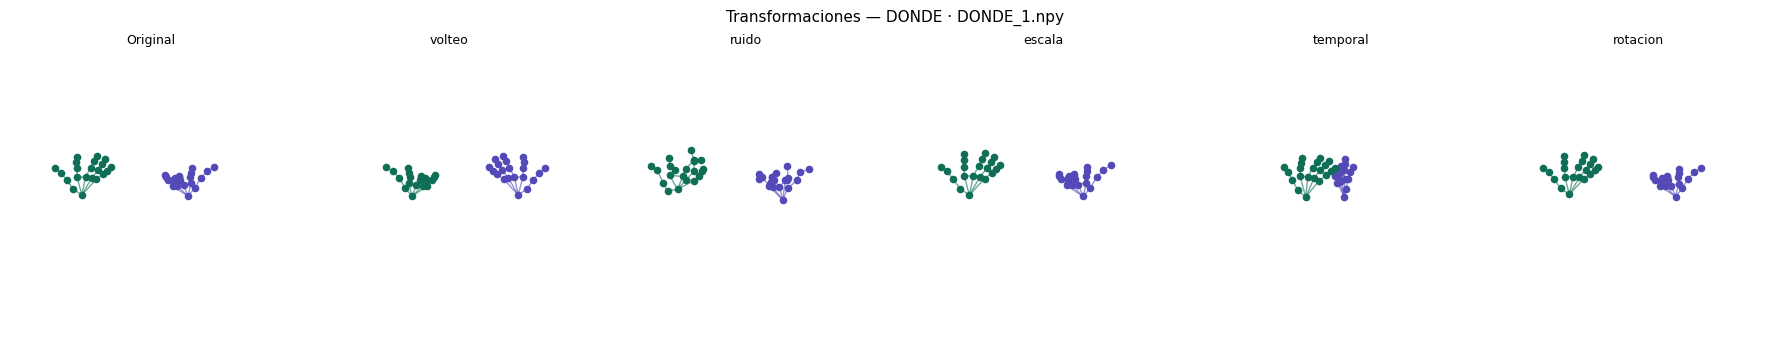

Imagen guardada en data/visualizacion_augmentation.png


In [18]:
def plot_frame_landmarks(ax, frame: np.ndarray, titulo: str = ''):
    """
    Dibuja los landmarks de un frame (2, 21, 3) en un eje matplotlib.
    Púrpura = mano derecha, verde = mano izquierda.
    """
    colores = ['#534AB7', '#0F6E56']
    nombres = ['Derecha', 'Izquierda']

    # Conexiones de MediaPipe Hands (pares de índices)
    conexiones = [
        (0,1),(1,2),(2,3),(3,4),           # pulgar
        (0,5),(5,6),(6,7),(7,8),           # índice
        (0,9),(9,10),(10,11),(11,12),      # medio
        (0,13),(13,14),(14,15),(15,16),    # anular
        (0,17),(17,18),(18,19),(19,20),    # meñique
        (5,9),(9,13),(13,17),              # palma
    ]

    for mano_idx, (color, nombre) in enumerate(zip(colores, nombres)):
        pts = frame[mano_idx]  # (21, 3)
        if not np.any(pts != 0):
            continue
        x, y = pts[:, 0], pts[:, 1]
        for i, j in conexiones:
            ax.plot([x[i], x[j]], [1 - y[i], 1 - y[j]],
                    color=color, linewidth=1, alpha=0.6)
        ax.scatter(x, 1 - y, c=color, s=20, zorder=5, label=nombre)

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')


# Cargar un clip de la primera clase
clase_prueba = CLASES[0]
npy_files = sorted((LANDMARKS_DIR / clase_prueba).glob('*.npy'))
landmarks_orig = np.load(npy_files[0])

# Elegir un frame del medio donde haya detección
frames_con_manos = np.where(
    np.any(landmarks_orig != 0, axis=(1, 2, 3))
)[0]
frame_idx = frames_con_manos[len(frames_con_manos) // 2]
frame_ref = landmarks_orig[frame_idx]

print(f'Clip: {npy_files[0].name}')
print(f'Frame de referencia: {frame_idx} de {len(landmarks_orig)}')

# Visualizar original + cada transformación
n_cols = len(TRANSFORMACIONES) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3, 3.5))

plot_frame_landmarks(axes[0], frame_ref, 'Original')

for i, (nombre, fn, kwargs) in enumerate(TRANSFORMACIONES):
    aug = fn(landmarks_orig, **kwargs)
    plot_frame_landmarks(axes[i + 1], aug[frame_idx], nombre)

plt.suptitle(f'Transformaciones — {clase_prueba} · {npy_files[0].name}',
             fontsize=11)
plt.tight_layout()
plt.savefig('./data/visualizacion_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada en data/visualizacion_augmentation.png')

## Sección 3 — Verificar que las transformaciones no rompen los landmarks

Revisamos que los valores generados son razonables (no NaN, no valores extremos).

In [19]:
print('Verificación de transformaciones:\n')
print(f'  Original → min: {landmarks_orig.min():.3f} max: {landmarks_orig.max():.3f} NaN: {np.isnan(landmarks_orig).any()}')

for nombre, fn, kwargs in TRANSFORMACIONES:
    aug = fn(landmarks_orig, **kwargs)
    tiene_nan = np.isnan(aug).any()
    estado = '⚠️  NaN detectado' if tiene_nan else 'OK'
    print(f'  {nombre:<12} → min: {aug.min():.3f} max: {aug.max():.3f} NaN: {tiene_nan} {estado}')

Verificación de transformaciones:

  Original → min: -0.091 max: 0.986 NaN: False
  volteo       → min: -0.091 max: 1.028 NaN: False OK
  ruido        → min: -0.093 max: 0.992 NaN: False OK
  escala       → min: -0.091 max: 1.006 NaN: False OK
  temporal     → min: -0.087 max: 0.830 NaN: False OK
  rotacion     → min: -0.091 max: 1.007 NaN: False OK


## Sección 4 — Generar todos los augmentados

In [20]:
def augmentar_clase(clase: str, landmarks_dir: Path, aug_dir: Path,
                    transformaciones: list, copiar_originales: bool = True):
    """
    Procesa todos los .npy de una clase y genera variantes augmentadas.
    También copia los originales a aug_dir para tenerlo todo en un lugar.
    """
    npy_files = sorted((landmarks_dir / clase).glob('*.npy'))
    output_dir = aug_dir / clase
    output_dir.mkdir(parents=True, exist_ok=True)

    n_orig = 0
    n_aug  = 0

    for npy_path in npy_files:
        landmarks = np.load(npy_path)

        # Copiar original
        if copiar_originales:
            dest = output_dir / npy_path.name
            if not dest.exists():
                shutil.copy(npy_path, dest)
            n_orig += 1

        # Generar una variante por transformación
        for nombre, fn, kwargs in transformaciones:
            aug_path = output_dir / f'{npy_path.stem}_aug_{nombre}.npy'
            if aug_path.exists():
                n_aug += 1
                continue
            aug = fn(landmarks, **kwargs)
            np.save(aug_path, aug)
            n_aug += 1

    return n_orig, n_aug


print('Generando augmentados...\n')
resumen = {}

for clase in CLASES:
    n_orig, n_aug = augmentar_clase(
        clase, LANDMARKS_DIR, AUG_DIR, TRANSFORMACIONES
    )
    resumen[clase] = {'originales': n_orig, 'augmentados': n_aug,
                      'total': n_orig + n_aug}
    print(f'  {clase:<15} {n_orig} originales + {n_aug} aug = {n_orig + n_aug} total')

total_clips = sum(v['total'] for v in resumen.values())
print(f'\n  TOTAL: {total_clips} clips listos para entrenar')

Generando augmentados...

  DONDE           11 originales + 55 aug = 66 total
  NADA            48 originales + 240 aug = 288 total
  POR_QUE         12 originales + 60 aug = 72 total
  QUE1            6 originales + 30 aug = 36 total
  QUIEN1          7 originales + 35 aug = 42 total

  TOTAL: 504 clips listos para entrenar


## Sección 5 — Verificación final del dataset

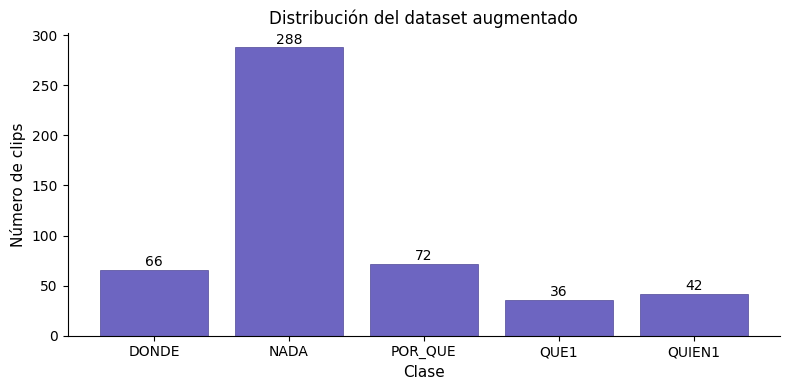

Imagen guardada en data/distribucion_dataset.png


In [21]:
# Distribución de clases
clases_counts = {}
for clase in CLASES:
    npy_files = list((AUG_DIR / clase).glob('*.npy'))
    clases_counts[clase] = len(npy_files)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(clases_counts.keys(), clases_counts.values(),
              color='#534AB7', alpha=0.85, edgecolor='#3C3489', linewidth=0.5)

for bar, v in zip(bars, clases_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(v), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Clase', fontsize=11)
ax.set_ylabel('Número de clips', fontsize=11)
ax.set_title('Distribución del dataset augmentado', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/distribucion_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada en data/distribucion_dataset.png')

In [22]:
# Verificar shapes consistentes
print('Verificación de shapes (todos deben ser (n_frames, 2, 21, 3)):\n')
errores = []

for clase in CLASES:
    npy_files = sorted((AUG_DIR / clase).glob('*.npy'))
    n_frames_list = []
    for npy in npy_files:
        arr = np.load(npy)
        if arr.shape[1:] != (2, 21, 3):
            errores.append(f'{clase}/{npy.name}: shape inesperado {arr.shape}')
        n_frames_list.append(arr.shape[0])
    if n_frames_list:
        print(f'  {clase:<15} frames: min={min(n_frames_list)} '
              f'max={max(n_frames_list)} prom={int(np.mean(n_frames_list))}')

if errores:
    print('\n⚠️  Errores encontrados:')
    for e in errores:
        print(f'  {e}')
else:
    print('\nTodo OK — dataset listo para el notebook de entrenamiento')

Verificación de shapes (todos deben ser (n_frames, 2, 21, 3)):

  DONDE           frames: min=11 max=123 prom=67
  NADA            frames: min=6 max=65 prom=19
  POR_QUE         frames: min=10 max=79 prom=47
  QUE1            frames: min=251 max=267 prom=261
  QUIEN1          frames: min=18 max=267 prom=230

Todo OK — dataset listo para el notebook de entrenamiento


---
## ¿Qué sigue?

Si la verificación pasó sin errores, el dataset está listo.

**`03_entrenamiento.ipynb`** — carga los `.npy` de `data/landmarks_aug/`, entrena un clasificador SVM como baseline y evalúa con matriz de confusión.